# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 2026-2027 — Major Project**

## 1. Introduction to the Dataset

This dataset captures agricultural activity across different **seasons** (Kharif, Rabi, Zaid), **states**, **districts** and **crops** in India. It records environmental conditions (rainfall, temperature, humidity, soil health), farming inputs (fertilizer, pesticide, irrigation method, seed quality), and outcomes (yield, production, cost, revenue, profit, water usage, and disease/pest risk) for **4,000 individual farms**.

## 2. Problem Statement

Agricultural performance is influenced by seasonal variation in environmental conditions, farming practices, resource availability and market conditions. Raw data alone does not reveal *how* performance changes across seasons or *what patterns* explain those differences.

**This project analyzes the dataset to investigate seasonal differences in agricultural performance** — identifying meaningful patterns, trends, relationships and variations across Kharif, Rabi and Zaid seasons.

## 3. Objective

To explore, clean, and analyze seasonal agricultural data in order to:
- Examine how yield, cost, revenue and profit vary across seasons
- Identify seasonal patterns in environmental conditions and resource use
- Investigate relationships between conditions (rainfall, humidity, temperature) and outcomes (yield, disease risk)
- Compare crops, states and irrigation methods across seasons
- Derive evidence-based insights and recommendations for seasonal agricultural planning

## 4. Key Analytical Questions

1. How does yield vary across seasons, and is the difference statistically significant?
2. How do environmental conditions (rainfall, temperature) differ by season?
3. How do costs, revenue and profit vary by season — and are farms actually profitable?
4. Do specific crops perform consistently well/poorly across all seasons?
5. Does irrigation method affect water-use efficiency, and does this vary by season?
6. Is disease/pest risk related to seasonal environmental conditions?
7. Which variables correlate most strongly with yield and profit?
8. Are seasonal patterns consistent across different states?

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#2e7d32', 'Rabi': '#1565c0', 'Zaid': '#e65100'}

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 5. Data Loading and Initial Exploration

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape of dataset:", df.shape)

Shape of dataset: (4000, 28)


In [3]:
df.head()

   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_pH  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53        486.4               24.3          69.1                 5.8     7.14   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53        855.4               25.7          78.4                 5.1     5.20   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86        455.6               23.9          56.4                10.3     5.82   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50        753.2               29.7          65.2                 6.3     5.98   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21        101.6               34.1          55.2                 6.5     6.90   

   Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha Irrigation_Method  Fe

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [5]:
# Summary statistics of numeric columns
df.describe().round(2)

       Farm_Area_Hectares  Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_pH  Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  \
count             4000.00      3952.00            4000.00       4000.00             4000.00  4000.00            3960.00         4000.00           4000.00   
mean                 7.89       601.15              26.82         63.21                7.32     6.70              26.51          120.25             57.78   
std                  4.22       288.93               3.82         11.96                1.12     0.64               6.71           31.22             17.02   
min                  0.50        80.00              16.20         25.00                3.50     5.20               8.00           40.00             15.00   
25%                  4.26       370.20              23.90         54.78                6.60     6.26              21.70           98.50             46.20   
50%                  7.90       582.00              26.90 

**Observations:**
- The dataset has **4,000 records** and **28 columns** covering farm identity, environment, inputs, and outcomes.
- Most columns are complete, but `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha` show missing values (checked below).
- `Yield_Tonnes_Ha` and `Water_Efficiency_t_per_1000m3` have very large maximums compared to their medians — a sign of outliers that need treatment.

## 6. Data Cleaning and Preparation

In [6]:
# Check missing values
df.isnull().sum()[df.isnull().sum() > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [7]:
# Check for duplicate records
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate Farm IDs:", df['Farm_ID'].duplicated().sum())

Number of duplicate rows: 0
Number of duplicate Farm IDs: 0


**Handling missing values:** Since `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` are strongly tied to *season* and *crop type*, missing values are filled using the **median for that Season + Crop combination** rather than a single global average — this preserves genuine seasonal and crop-level differences instead of flattening them.

In [8]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

print("Missing values remaining:", df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum().sum())

Missing values after imputation: 0


In [9]:
# Inspect potential outliers
df[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']].describe().round(2)

       Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3
count          4000.00                        4000.00
mean              5.27                           5.39
std              13.34                           8.84
min               0.30                           0.14
25%               1.05                           1.66
50%               1.74                           2.94
75%               2.84                           5.15
max             101.44                          79.80


**Handling outliers:** `Yield_Tonnes_Ha` (max ≈101 t/ha vs. a median of ~1.7) and `Water_Efficiency_t_per_1000m3` (max ≈80 vs. median ~2.9) contain extreme values that are almost certainly data-entry errors, since they are far beyond realistic field yields. These are treated using the **IQR capping method** (values beyond 1.5×IQR from Q1/Q3 are capped to that bound), which reduces distortion while preserving all 4,000 records for analysis.

In [10]:
def cap_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

df['Yield_Tonnes_Ha_capped'] = cap_outliers(df['Yield_Tonnes_Ha'])
df['Water_Efficiency_capped'] = cap_outliers(df['Water_Efficiency_t_per_1000m3'])

print("Yield max before capping: %.2f | after capping: %.2f" % (df['Yield_Tonnes_Ha'].max(), df['Yield_Tonnes_Ha_capped'].max()))
print("Water efficiency max before capping: %.2f | after capping: %.2f" % (df['Water_Efficiency_t_per_1000m3'].max(), df['Water_Efficiency_capped'].max()))

Yield max before capping: 101.44 | after capping: 5.52
Water efficiency max before capping: 79.80 | after capping: 10.38


## 7. Exploratory Data Analysis — Seasonal Overview

In [11]:
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


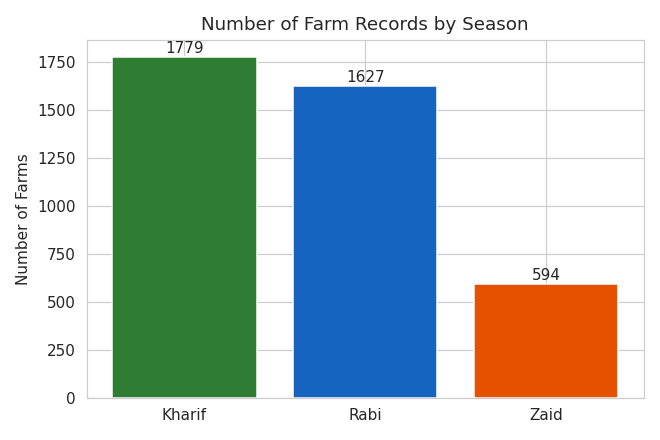

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df['Season'].value_counts().reindex(SEASON_ORDER)
ax.bar(counts.index, counts.values, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
ax.set_title('Number of Farm Records by Season')
ax.set_ylabel('Number of Farms')
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha='center')
plt.tight_layout()
plt.show()

**Q1: How does yield vary across seasons?** Kharif has the most records (1,779), followed by Rabi (1,627) and Zaid (594) — consistent with Zaid being a short, less widely cultivated summer season in Indian agriculture.

In [13]:
yield_summary = df.groupby('Season')['Yield_Tonnes_Ha_capped'].agg(['mean','median','std']).round(2)
yield_summary.reindex(SEASON_ORDER)

        mean  median   std
Season                    
Kharif  2.26    1.95  1.43
Rabi    2.04    1.66  1.41
Zaid    1.81    1.45  1.39


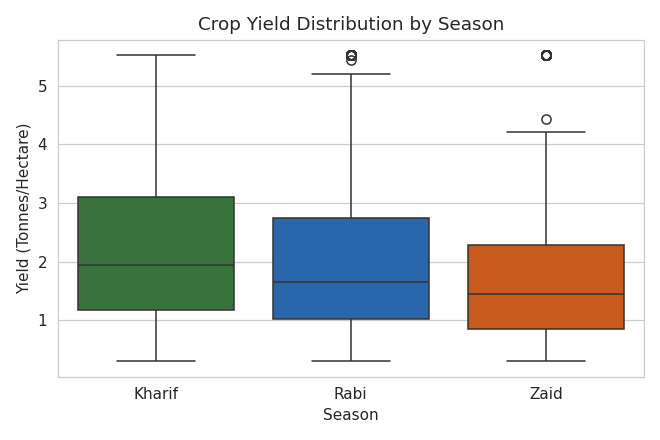

In [14]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha_capped', order=SEASON_ORDER,
            hue='Season', palette=SEASON_COLORS, legend=False, ax=ax)
ax.set_title('Crop Yield Distribution by Season')
ax.set_ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()

**Q2: How do environmental conditions differ by season?** Kharif is the monsoon-driven season, Rabi is the cooler winter season, and Zaid is the hot, dry summer season.

In [15]:
env_summary = df.groupby('Season')[['Rainfall_mm','Avg_Temperature_C','Humidity_pct']].mean().round(2)
env_summary.reindex(SEASON_ORDER)

        Rainfall_mm  Avg_Temperature_C  Humidity_pct
Season                                              
Kharif       852.10              28.45         71.81
Rabi         435.95              23.49         57.89
Zaid         299.16              31.04         52.01


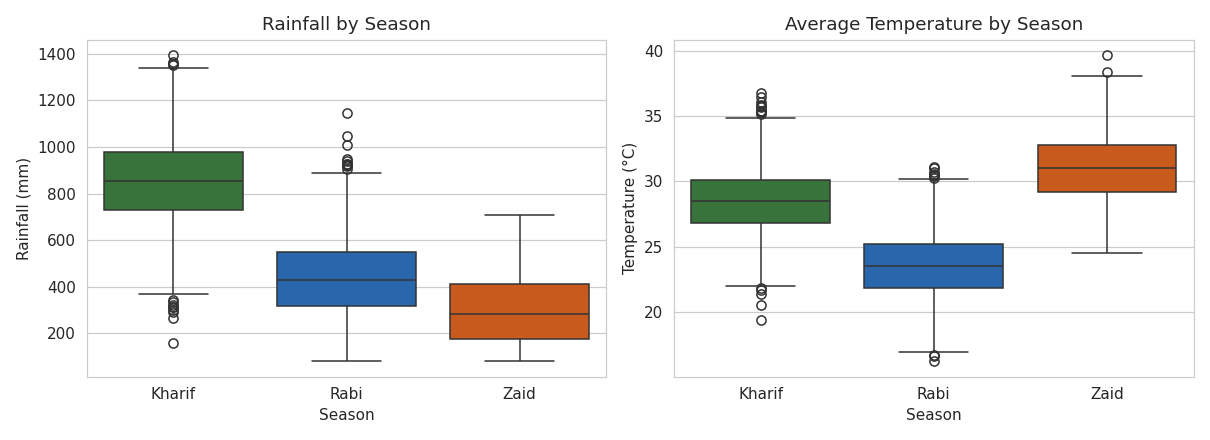

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=SEASON_ORDER, hue='Season',
            palette=SEASON_COLORS, legend=False, ax=axes[0])
axes[0].set_title('Rainfall by Season'); axes[0].set_ylabel('Rainfall (mm)')
sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', order=SEASON_ORDER, hue='Season',
            palette=SEASON_COLORS, legend=False, ax=axes[1])
axes[1].set_title('Average Temperature by Season'); axes[1].set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

**Statistical test:** Is the yield difference across seasons statistically significant, or could it be due to chance? A one-way ANOVA test is used since there are three independent seasonal groups.

In [17]:
groups = [g['Yield_Tonnes_Ha_capped'].values for _, g in df.groupby('Season')]
f_stat, p_val = stats.f_oneway(*groups)
print("One-way ANOVA -> Yield across Seasons: F = %.3f, p-value = %.6f" % (f_stat, p_val))
if p_val < 0.05:
    print("Result: Statistically significant difference in yield across seasons (p < 0.05)")
else:
    print("Result: No statistically significant difference in yield across seasons")

One-way ANOVA -> Yield across Seasons: F = 25.048, p-value = 0.000000
Result: Statistically significant difference in yield across seasons (p < 0.05)


## 8. Economic Performance Across Seasons

In [18]:
econ_summary = df.groupby('Season')[['Total_Cost_INR','Revenue_INR','Profit_INR']].mean().round(0)
econ_summary.reindex(SEASON_ORDER)

        Total_Cost_INR  Revenue_INR  Profit_INR
Season                                         
Kharif        531804.0     710719.0    178915.0
Rabi          513837.0     601526.0     87689.0
Zaid          543977.0     519172.0    -24805.0


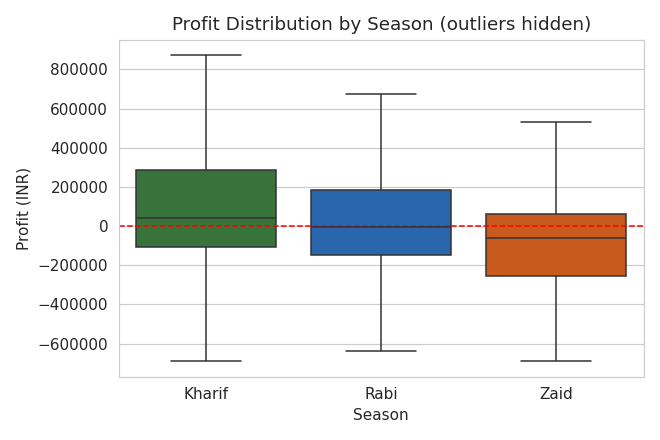

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, hue='Season',
            palette=SEASON_COLORS, legend=False, ax=ax, showfliers=False)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Profit Distribution by Season (outliers hidden for clarity)')
ax.set_ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

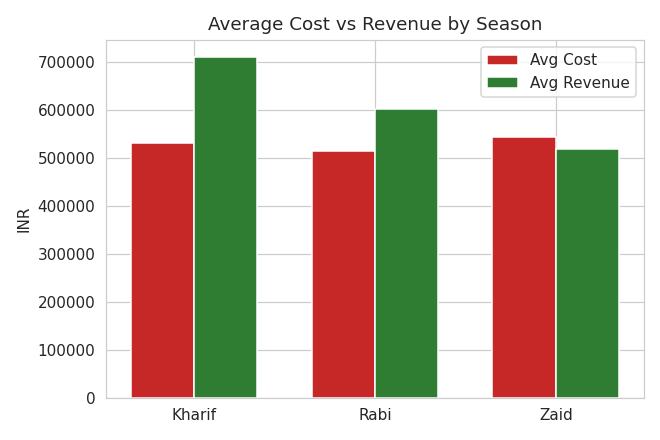

In [20]:
summ = df.groupby('Season')[['Total_Cost_INR','Revenue_INR']].mean().reindex(SEASON_ORDER)
fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(len(SEASON_ORDER)); w = 0.35
ax.bar(x - w/2, summ['Total_Cost_INR'], w, label='Avg Cost', color='#c62828')
ax.bar(x + w/2, summ['Revenue_INR'], w, label='Avg Revenue', color='#2e7d32')
ax.set_xticks(x); ax.set_xticklabels(SEASON_ORDER)
ax.set_ylabel('INR'); ax.set_title('Average Cost vs Revenue by Season')
ax.legend()
plt.tight_layout()
plt.show()

**Q3: Are farms actually profitable, and does this vary by season?** The profit margin (% of revenue kept as profit) and the share of farms operating at a loss reveal a much more concerning picture than average profit alone.

In [21]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Loss'] = df['Profit_INR'] < 0
margin_loss = df.groupby('Season').agg(
    Avg_Profit_Margin_pct=('Profit_Margin_pct', 'mean'),
    Pct_LossMaking_Farms=('Loss', lambda x: round(x.mean()*100, 1))
)
margin_loss.reindex(SEASON_ORDER)

        Avg_Profit_Margin_pct  Pct_LossMaking_Farms
Season                                             
Kharif             -38.644541                  42.2
Rabi               -44.267645                  51.1
Zaid               -69.354573                  64.5


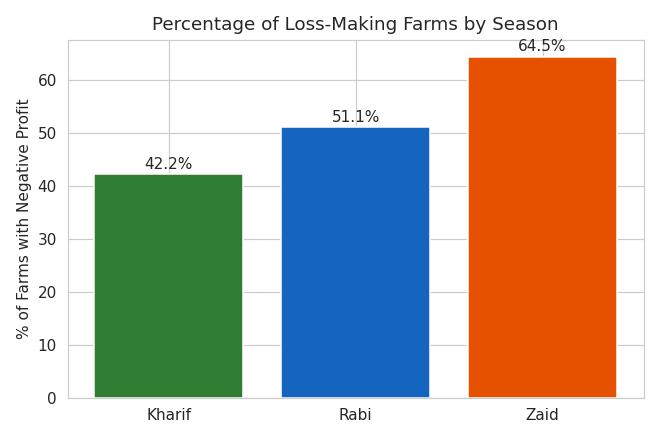

In [22]:
loss_pct = df.groupby('Season')['Loss'].mean().reindex(SEASON_ORDER) * 100
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(loss_pct.index, loss_pct.values, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
ax.set_title('Percentage of Loss-Making Farms by Season')
ax.set_ylabel('% of Farms with Negative Profit')
for i, v in enumerate(loss_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

In [23]:
groups_p = [g['Profit_INR'].values for _, g in df.groupby('Season')]
f2, p2 = stats.f_oneway(*groups_p)
print("One-way ANOVA -> Profit across Seasons: F = %.3f, p-value = %.6f" % (f2, p2))

One-way ANOVA -> Profit across Seasons: F = 34.292, p-value = 0.000000


## 9. Crop–Season Interaction

**Q4: Do specific crops perform consistently well or poorly across all seasons?** Average yield and loss-rate are compared for each crop within each season.

In [24]:
pivot_yield = df.pivot_table(values='Yield_Tonnes_Ha_capped', index='Crop', columns='Season',
                              aggfunc='mean')[SEASON_ORDER].round(2)
pivot_yield

Season     Kharif  Rabi  Zaid
Crop                         
Chilli       1.73  1.46  1.18
Cotton       1.37  1.19  0.95
Groundnut    1.48  1.22  1.04
Maize        2.96  2.62  2.30
Pulses       1.04  0.87  0.65
Rice         2.71  2.33  1.90
Sugarcane    5.46  5.46  5.44
Wheat        2.26  2.06  1.75


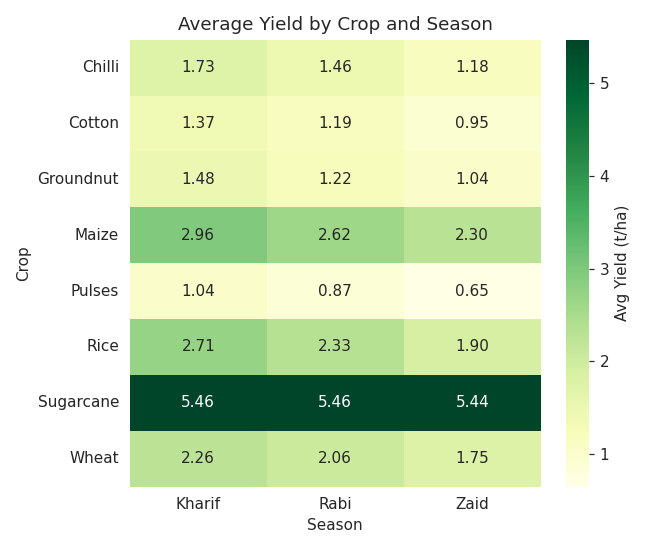

In [25]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGn', ax=ax, cbar_kws={'label': 'Avg Yield (t/ha)'})
ax.set_title('Average Yield by Crop and Season')
plt.tight_layout()
plt.show()

In [26]:
pivot_loss = (df.pivot_table(values='Loss', index='Crop', columns='Season',
                              aggfunc='mean')[SEASON_ORDER] * 100).round(1)
pivot_loss

Season     Kharif  Rabi  Zaid
Crop                         
Chilli       14.6  21.5  18.8
Cotton       27.9  33.8  52.2
Groundnut    33.2  43.5  59.3
Maize        53.4  66.5  84.5
Pulses       37.1  54.0  75.8
Rice         58.6  67.5  87.3
Sugarcane     8.0  14.7  11.8
Wheat        68.2  75.1  91.8


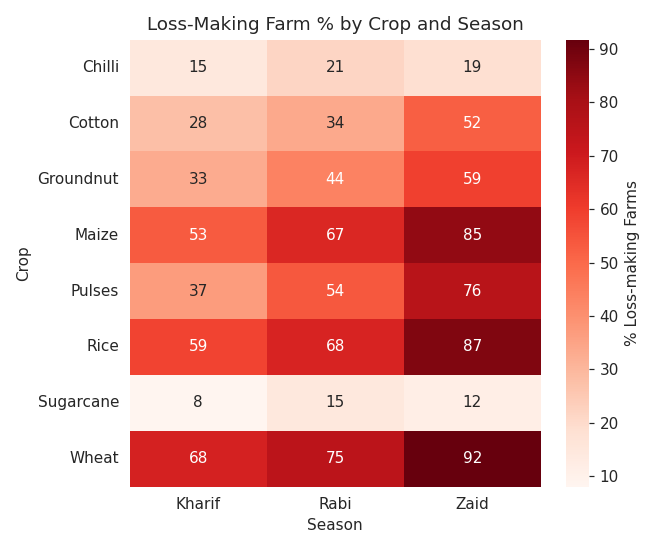

In [27]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(pivot_loss, annot=True, fmt='.0f', cmap='Reds', ax=ax, cbar_kws={'label': '% Loss-making Farms'})
ax.set_title('Loss-Making Farm % by Crop and Season')
plt.tight_layout()
plt.show()

## 10. Resource Usage — Irrigation and Water Efficiency

**Q5: Does irrigation method affect water-use efficiency, and does this vary by season?**

In [28]:
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').reindex(SEASON_ORDER) * 100
irrigation_season.round(1)

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             22.8   33.2     26.0       18.0
Rabi               22.7   32.3     26.9       18.0
Zaid               23.6   32.7     23.6       20.2


In [29]:
water_eff_irr = df.groupby('Irrigation_Method')['Water_Efficiency_capped'].mean().sort_values(ascending=False).round(2)
water_eff_irr

Irrigation_Method
Rainfed      5.19
Drip         4.08
Sprinkler    3.48
Flood        2.67
Name: Water_Efficiency_capped, dtype: float64


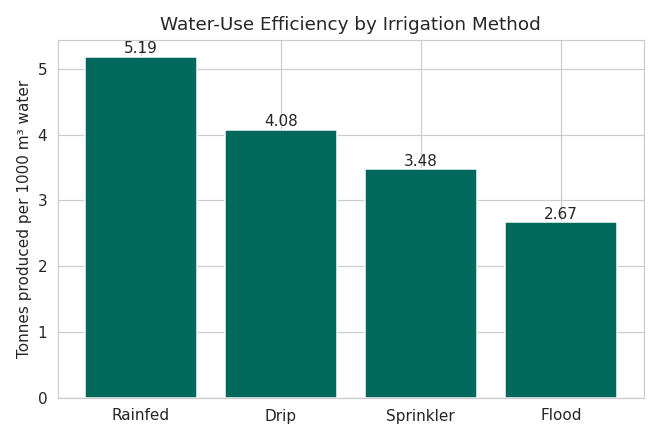

In [30]:
fig, ax = plt.subplots(figsize=(6,4))
we = water_eff_irr
ax.bar(we.index, we.values, color='#00695c')
ax.set_title('Water-Use Efficiency by Irrigation Method')
ax.set_ylabel('Tonnes produced per 1000 m³ water')
for i, v in enumerate(we.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

**Note:** Irrigation method *mix* stays fairly stable across seasons (Flood ~32–33%, Rainfed ~24–27%, Drip ~23%, Sprinkler ~18–20%), but efficiency differs sharply between methods — irrespective of season.

## 11. Disease / Pest Risk Patterns

**Q6: Is disease/pest risk related to seasonal environmental conditions?**

In [31]:
disease_season = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(SEASON_ORDER).round(2)
disease_season

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


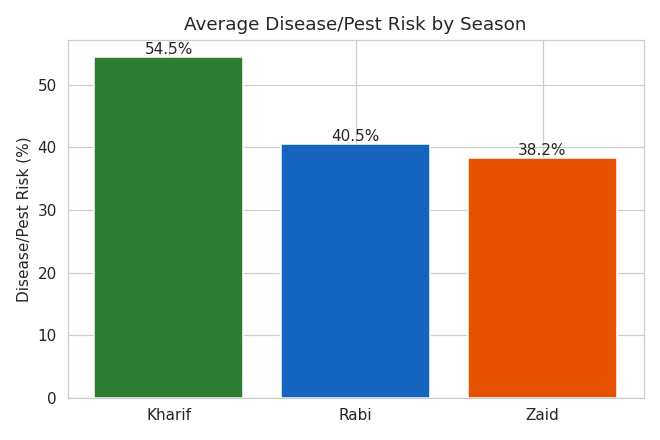

In [32]:
fig, ax = plt.subplots(figsize=(6,4))
dr = disease_season
ax.bar(dr.index, dr.values, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
ax.set_title('Average Disease/Pest Risk by Season')
ax.set_ylabel('Disease/Pest Risk (%)')
for i, v in enumerate(dr.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

In [33]:
disease_corr = df[['Disease_Pest_Risk_pct','Humidity_pct','Rainfall_mm','Avg_Temperature_C']].corr().round(2)
disease_corr

                       Disease_Pest_Risk_pct  Humidity_pct  Rainfall_mm  Avg_Temperature_C
Disease_Pest_Risk_pct                   1.00          0.55         0.62               0.25
Humidity_pct                            0.55          1.00         0.53               0.14
Rainfall_mm                             0.62          0.53         1.00               0.20
Avg_Temperature_C                       0.25          0.14         0.20               1.00


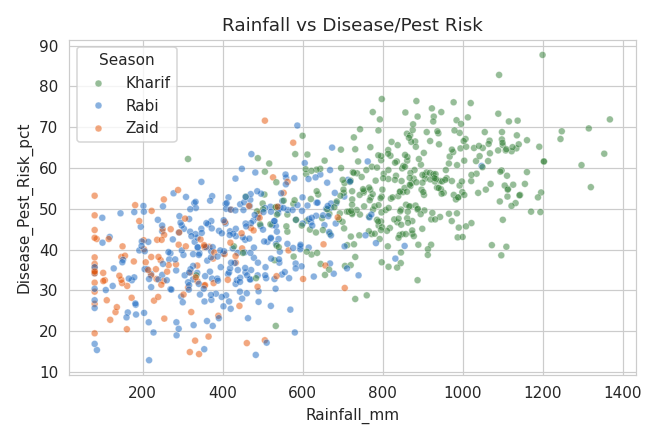

In [34]:
fig, ax = plt.subplots(figsize=(6,4))
sample = df.sample(800, random_state=1)
sns.scatterplot(data=sample, x='Rainfall_mm', y='Disease_Pest_Risk_pct', hue='Season',
                 palette=SEASON_COLORS, hue_order=SEASON_ORDER, alpha=0.5, ax=ax, s=20)
ax.set_title('Rainfall vs Disease/Pest Risk')
plt.tight_layout()
plt.show()

## 12. Correlation Analysis

**Q7: Which variables correlate most strongly with yield and profit?**

In [35]:
cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct','Fertilizer_kg_ha',
        'Yield_Tonnes_Ha_capped','Profit_INR','Water_Efficiency_capped','Disease_Pest_Risk_pct']
corr_matrix = df[cols].corr().round(2)
corr_matrix

                         Rainfall_mm  Avg_Temperature_C  Humidity_pct  Soil_Moisture_pct  Fertilizer_kg_ha  Yield_Tonnes_Ha_capped  Profit_INR  \
Rainfall_mm                     1.00               0.20          0.53               0.52              0.02                    0.10        0.11   
Avg_Temperature_C               0.20               1.00          0.14               0.08              0.02                    0.00        0.01   
Humidity_pct                    0.53               0.14          1.00               0.45              0.02                    0.06        0.06   
Soil_Moisture_pct               0.52               0.08          0.45               1.00              0.01                    0.08        0.09   
Fertilizer_kg_ha                0.02               0.02          0.02               0.01              1.00                    0.00       -0.07   
Yield_Tonnes_Ha_capped          0.10               0.00          0.06               0.08              0.00                  

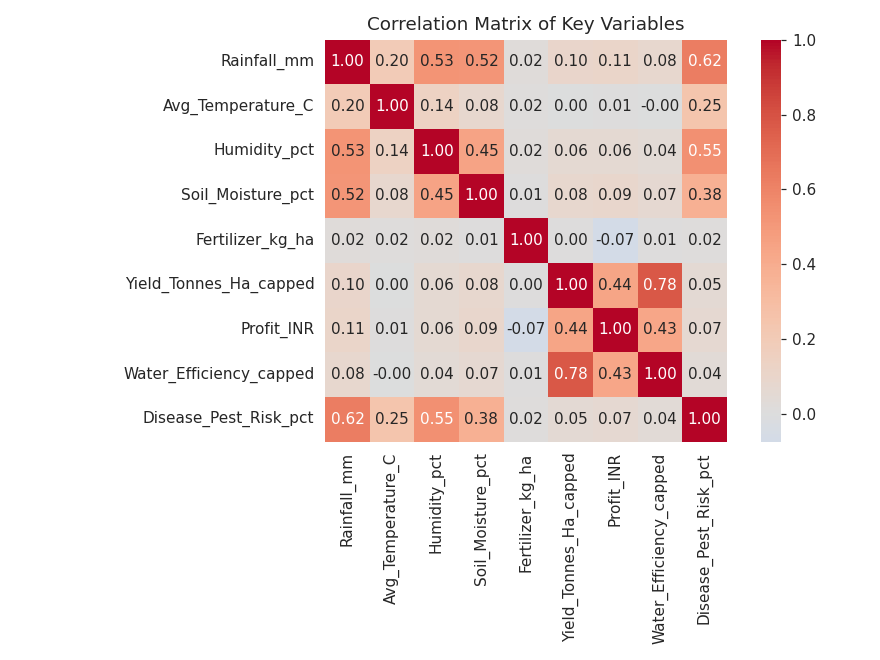

In [36]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()

## 13. State-wise Seasonal Patterns

**Q8: Are seasonal patterns consistent across different states?**

In [37]:
state_summary = df.groupby('State').agg(Avg_Yield=('Yield_Tonnes_Ha_capped','mean'),
                                          Avg_Profit=('Profit_INR','mean'),
                                          Avg_DiseaseRisk=('Disease_Pest_Risk_pct','mean')).round(2)
state_summary.sort_values('Avg_Profit', ascending=False)

                Avg_Yield  Avg_Profit  Avg_DiseaseRisk
State                                                 
Punjab               2.19   136025.64            46.00
Maharashtra          2.10   135428.86            46.44
Karnataka            2.17   119422.34            46.06
Tamil Nadu           2.05   117744.75            46.28
Gujarat              2.08   117568.24            45.95
Telangana            2.19   108829.62            46.36
Madhya Pradesh       2.04    86840.76            47.08
Andhra Pradesh       2.01    73453.53            46.72


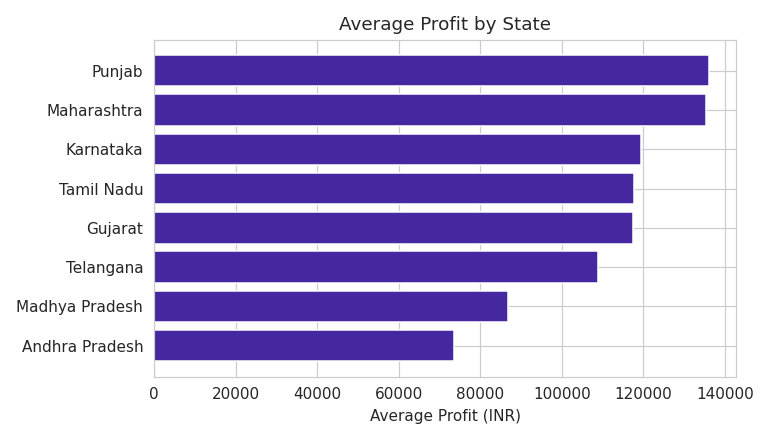

In [38]:
fig, ax = plt.subplots(figsize=(7,4))
st = df.groupby('State')['Profit_INR'].mean().sort_values()
ax.barh(st.index, st.values, color='#4527a0')
ax.set_title('Average Profit by State')
ax.set_xlabel('Average Profit (INR)')
plt.tight_layout()
plt.show()

## 14. Key Insights and Findings

1. **Kharif is the strongest season overall.** It has the highest average yield (2.26 t/ha), highest average profit (≈₹1.79 lakh/farm), and the highest rainfall (852 mm) — monsoon conditions clearly favour production, despite also carrying the highest disease/pest risk (54.5%).

2. **Zaid is the weakest season economically.** It has the lowest average yield (1.81 t/ha), lowest rainfall (299 mm) and highest temperature (31.0°C), and is the *only* season with a **negative average profit** (≈ −₹24,800/farm) and a −69% average profit margin.

3. **Most farms are loss-making, and this gets worse through the season cycle.** 42% of Kharif farms operate at a loss, rising to 51% in Rabi and **64.5% in Zaid** — a season-by-season deterioration in farm-level profitability that is easy to miss if only looking at averages.

4. **Yield and profit differences across seasons are statistically significant** (ANOVA: Yield p < 0.001, Profit p < 0.001), confirming these are genuine seasonal effects, not random variation.

5. **Crop choice matters more than season alone.** Sugarcane is remarkably stable and profitable across all three seasons (yield ~5.44–5.46 t/ha, only 8–15% loss-making farms), while **Wheat is consistently the highest-risk crop** (68–92% of farms loss-making depending on season) despite reasonable yields — pointing to a cost/price problem rather than a production problem.

6. **Irrigation method drives water efficiency far more than season does.** Rainfed farming shows the highest water-use efficiency (5.19 t per 1000 m³), while Flood irrigation — the most commonly used method (~33% of farms) — is the least efficient (2.67 t per 1000 m³).

7. **Disease/pest risk is strongly linked to wetter conditions**, correlating positively with rainfall (r = 0.62) and humidity (r = 0.55), explaining why Kharif consistently shows the highest disease pressure.

8. **Yield and profit are only weakly correlated with fertilizer use and rainfall individually** (r ≈ 0.1), suggesting outcomes are driven by a combination of factors (crop type, irrigation, market price) rather than any single input.

9. **State-level profitability varies substantially** even after accounting for season: Punjab and Maharashtra show the highest average profit, while Andhra Pradesh and Madhya Pradesh trail behind — indicating regional factors (market access, soil, practices) compound seasonal effects.

## 15. Recommendations

- **Prioritize Kharif-season planning and protection.** Since Kharif offers the best yield and profit potential, invest in disease/pest management (given its highest risk score) to protect these already-strong returns.
- **Re-evaluate Zaid-season cultivation.** With negative average profit and the highest loss rate, farmers and planners should consider higher-value/low-water crops, improved pricing support, or reduced cultivation area for this season unless conditions can be improved (e.g., better irrigation access).
- **Investigate Wheat's cost structure.** Despite moderate yields, Wheat shows the highest loss rates across all seasons — this points to a cost or market-price issue that needs separate investigation (input costs, MSP/procurement price, or market access) rather than a yield issue.
- **Promote crop diversification toward stable performers like Sugarcane** where climate and soil conditions allow, to reduce farm-level financial risk.
- **Shift irrigation investment toward efficient methods.** Encouraging a shift from Flood irrigation (lowest efficiency, most widely used) toward Drip or well-managed Rainfed systems could meaningfully improve water-use efficiency without waiting for rainfall patterns to change.
- **Target disease/pest advisories to high-humidity, high-rainfall periods**, particularly during Kharif, since risk rises predictably with these conditions.
- **Use state-specific benchmarks, not just seasonal ones**, when advising farmers — since profitability gaps between states persist within the same season.

## 16. Conclusion

This analysis confirms that **season is a statistically significant driver of both yield and profitability**, but it is not the only one — crop choice, irrigation method, and location interact with seasonal conditions to shape outcomes. The most urgent finding is that a **majority of farms are operating at a loss**, with the situation worsening from Kharif to Zaid. This suggests seasonal agricultural planning should focus not just on maximizing yield, but on **closing the gap between production outcomes and economic viability** — particularly for Zaid-season and Wheat cultivation, where the data shows the greatest financial risk.